# Investigación inicial de datasets candidatos

Comparación documental de 3 fuentes candidatas. Los tamaños de HCV y ausentismo corresponden a los archivos CSV.

## 1. HCV Data

- **Fuente:** UCI Machine Learning Repository, repositorio académico. [Ficha y descarga](https://archive.ics.uci.edu/dataset/571/hcv+data).
- **Tipo:** datos tabulares clínicos; clasificación y agrupamiento.
- **Registros y atributos:** 615 pacientes. El CSV local contiene 14 columnas (ID, diagnóstico, edad, sexo y 10 resultados de laboratorio); UCI describe 12 features, excluyendo ID y variable objetivo de su conteo.
- **Variables:** categoría diagnóstica (donante, sospecha, hepatitis, fibrosis o cirrosis), edad, sexo y marcadores como ALB, ALP, ALT, AST, bilirrubina, colesterol, creatinina, GGT y proteínas.
- **Documentación:** ficha UCI y artículo de Hoffmann, Bietenbeck, Lichtinghagen y Klawonn (2018).
- **Aplicaciones posibles:** clasificación de categorías diagnósticas y exploración de relaciones entre variables clínicas.
- **Ventajas:** tamaño manejable, variables clínicas bien descritas y etiquetas para clasificación.
- **Limitaciones:** UCI reporta valores faltantes; son datos observacionales y no permiten inferir causalidad ni generalizar sin considerar la población de origen.

## 2. Absenteeism at Work

- **Fuente:** UCI Machine Learning Repository, repositorio académico. [Ficha y descarga](https://archive.ics.uci.edu/dataset/445/absenteeism+at+work).
- **Tipo:** datos tabulares con componente temporal; clasificación y agrupamiento.
- **Registros y atributos:** 740 registros. El CSV local tiene 21 columnas, incluido ID y objetivo; UCI reporta 19 features según su convención.
- **Variables:** motivo, mes, día y estación de la ausencia; gasto de transporte, distancia, antigüedad, edad, carga laboral, educación, datos familiares y sociales, y horas de ausencia.
- **Documentación:** ficha UCI, que describe registros de una empresa de mensajería en Brasil entre julio de 2007 y julio de 2010; incluye información de atributos y archivos de apoyo.
- **Aplicaciones posibles:** estudiar patrones de ausentismo y clasificar o agrupar registros según sus características.
- **Ventajas:** objetivo medible en horas, contexto temporal y documentación de variables; UCI indica que no presenta valores faltantes.
- **Limitaciones:** procede de una sola empresa y periodo; algunas variables están codificadas y requieren interpretar sus categorías.

## 3. Ajwa or Medjool

- **Fuente:** UCI Machine Learning Repository, repositorio académico. [Ficha y descarga](https://archive.ics.uci.edu/dataset/879/ajwa+or+medjool).
- **Tipo:** imágenes y datos tabulares; clasificación binaria de dátiles saudíes Ajwa y Medjool.
- **Registros y atributos:** 200 imágenes de 20 frutos. Incluye una tabla de características manuales (6 features y clase objetivo) y cuatro CSV de representaciones generadas con modelos de imágenes, cada uno con 200 filas.
- **Variables:** longitud, diámetro, peso, longitud del carozo, calorías, color y clase; los embeddings contienen atributos extraídos automáticamente de imágenes.
- **Documentación:** ficha UCI y artículo de Ghassan F. Bati (2023), *Ajwa or Medjool: A Binary balanced dataset to teach machine learning*.
- **Aplicaciones posibles:** clasificación de variedades mediante medidas, imágenes o características extraídas automáticamente.
- **Ventajas:** ofrece modalidades visual y tabular, clases balanceadas y distintos niveles de representación.
- **Limitaciones:** conjunto pequeño de 20 frutos; imágenes repetidas del mismo fruto no son observaciones independientes y pueden limitar la generalización.

# Comparación de los datasets y selección

Con la información de arriba ya podemos comparar las tres bases. Usamos los criterios que pide el enunciado (completitud, relevancia, documentación y manejabilidad) y le sumamos otros que nos sirven para las fases que siguen: tamaño, calidad de las variables, facilidad para hacer el EDA, posibilidades de preprocesamiento y posibilidades de reducción de dimensionalidad.

HCV Data y Absenteeism at Work están descargados en `data/raw`, así que a esos dos les medimos la calidad directamente con pandas. Ajwa or Medjool no lo bajamos al repositorio porque la descarga completa pesa cerca de 297.5 MB (imágenes, embeddings y varios CSV), entonces lo evaluamos con lo que dice su ficha en UCI y su repositorio oficial.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

RUTA_RAW = Path("..") / "data" / "raw"
RUTA_IMAGENES = Path("..") / "images"

ARCHIVO_HCV = RUTA_RAW / "hcvdat0.csv"
ARCHIVO_AUSENTISMO = RUTA_RAW / "Absenteeism_at_work.csv"

# La primera columna del CSV de HCV no tiene nombre, es solo el número de fila
df_hcv = pd.read_csv(ARCHIVO_HCV, index_col=0)
# El CSV de ausentismo viene separado por punto y coma
df_ausentismo = pd.read_csv(ARCHIVO_AUSENTISMO, sep=";")

print("HCV Data:", df_hcv.shape)
print("Absenteeism at Work:", df_ausentismo.shape)

HCV Data: (615, 13)
Absenteeism at Work: (740, 21)


## 1. Completitud y calidad general

Para no repetir el mismo código con cada dataset, armamos una función que saca los indicadores básicos de calidad que vimos en la guía de la semana 3: cuántos datos faltan, cuántas filas están duplicadas y de qué tipo son las columnas.

In [2]:
def resumen_calidad(df, nombre, archivo):
    # Indicadores básicos de completitud y calidad de un DataFrame
    celdas_faltantes = df.isna().sum().sum()
    return {
        "dataset": nombre,
        "registros": df.shape[0],
        "atributos": df.shape[1],
        "tamaño del archivo (KB)": round(archivo.stat().st_size / 1024, 1),
        "celdas faltantes": celdas_faltantes,
        "% de celdas faltantes": round(celdas_faltantes / df.size * 100, 2),
        "filas con algún faltante": df.isna().any(axis=1).sum(),
        "filas duplicadas": df.duplicated().sum(),
        "columnas numéricas": df.select_dtypes(include="number").shape[1],
        "columnas de texto": df.select_dtypes(exclude="number").shape[1],
    }


resumen = pd.DataFrame([
    resumen_calidad(df_hcv, "HCV Data", ARCHIVO_HCV),
    resumen_calidad(df_ausentismo, "Absenteeism at Work", ARCHIVO_AUSENTISMO),
]).set_index("dataset")

resumen

,registros,atributos,tamaño del archivo (KB),celdas faltantes,% de celdas faltantes,filas con algún faltante,filas duplicadas,columnas numéricas,columnas de texto
dataset,,,,,,,,,
HCV Data,615,13,45.1,31,0.39,26,0,11,2
Absenteeism at Work,740,21,44.2,0,0.00,0,34,21,0


In [3]:
# Faltantes por columna en HCV (Absenteeism no tiene ninguno)
faltantes_hcv = df_hcv.isna().sum()
faltantes_hcv = faltantes_hcv[faltantes_hcv > 0].sort_values(ascending=False).to_frame("faltantes")
faltantes_hcv["% del total de registros"] = (faltantes_hcv["faltantes"] / len(df_hcv) * 100).round(2)
faltantes_hcv

,faltantes,% del total de registros
ALP,18,2.93
CHOL,10,1.63
ALB,1,0.16
ALT,1,0.16
PROT,1,0.16


**Lo que muestran las tablas:**

- HCV tiene 31 celdas vacías de 7995 (0.39 %), repartidas en 26 pacientes. Casi todas están en `ALP` (18) y `CHOL` (10). Es poco, pero no es cero, así que en el EDA toca revisarlas y decidir cómo tratarlas.
- Absenteeism no tiene faltantes, pero sí 34 filas repetidas. Como el dataset no trae la fecha exacta de cada ausencia (solo mes y día de la semana), no hay forma de saber si son duplicados por error o ausencias distintas que quedaron iguales.
- Los dos archivos pesan alrededor de 45 KB, entonces en manejabilidad están parejos.
- El conteo de columnas numéricas engaña un poco: en Absenteeism las 21 columnas salen como numéricas, pero varias son códigos. Eso lo revisamos en el siguiente punto.

## 2. Consistencia de las variables

Que un dataset no tenga faltantes no quiere decir que esté limpio. Revisamos si los valores tienen sentido según la documentación de cada base.

In [4]:
# Según la ficha de UCI, estas columnas de ausentismo son códigos de categorías aunque vengan como números
columnas_codificadas = [
    "Reason for absence", "Month of absence", "Day of the week", "Seasons",
    "Education", "Disciplinary failure", "Social drinker", "Social smoker",
]
motivo_cero = df_ausentismo["Reason for absence"] == 0

print("Columnas que en realidad son códigos:", len(columnas_codificadas), "de", df_ausentismo.shape[1])
print("Empleados distintos (ID):", df_ausentismo["ID"].nunique())
print("Máximo de registros de un mismo empleado:", df_ausentismo["ID"].value_counts().max())
print("Registros con mes 0 (ese mes no existe):", (df_ausentismo["Month of absence"] == 0).sum())
print("Registros con motivo 0 (no aparece en la ficha):", motivo_cero.sum())
print("  - de esos, con 0 horas de ausencia:", (df_ausentismo.loc[motivo_cero, "Absenteeism time in hours"] == 0).sum())
print("  - de esos, con falta disciplinaria:", (df_ausentismo.loc[motivo_cero, "Disciplinary failure"] == 1).sum())

Columnas que en realidad son códigos: 8 de 21
Empleados distintos (ID): 36
Máximo de registros de un mismo empleado: 113
Registros con mes 0 (ese mes no existe): 3
Registros con motivo 0 (no aparece en la ficha): 43
  - de esos, con 0 horas de ausencia: 43
  - de esos, con falta disciplinaria: 40


In [5]:
# Distribución del diagnóstico en HCV
diagnosticos = df_hcv["Category"].value_counts().to_frame("pacientes")
diagnosticos["porcentaje"] = (diagnosticos["pacientes"] / len(df_hcv) * 100).round(2)
diagnosticos

,pacientes,porcentaje
Category,,
0=Blood Donor,533,86.67
3=Cirrhosis,30,4.88
1=Hepatitis,24,3.90
2=Fibrosis,21,3.41
0s=suspect Blood Donor,7,1.14


In [6]:
# Rango de cada marcador de laboratorio, para ver qué tan distintas son sus escalas
columnas_laboratorio = ["ALB", "ALP", "ALT", "AST", "BIL", "CHE", "CHOL", "CREA", "GGT", "PROT"]
df_hcv[columnas_laboratorio].agg(["min", "max"]).T

,min,max
ALB,14.90,82.20
ALP,11.30,416.60
ALT,0.90,325.30
AST,10.60,324.00
BIL,0.80,254.00
CHE,1.42,16.41
CHOL,1.43,9.67
CREA,8.00,1079.10
GGT,4.50,650.90
PROT,44.80,90.00


**Lo que encontramos:**

- En Absenteeism, 8 de las 21 columnas son códigos que pandas lee como números (motivo, mes, día, estación, educación y tres variables de sí/no). Si no se lee la ficha, uno termina sacando cosas como el "mes promedio", que no tiene sentido.
- Hay 3 registros con mes 0, que no existe, y 43 con motivo 0, que no está en la lista de motivos de UCI. Los 43 tienen 0 horas de ausencia y en 40 de ellos `Disciplinary failure` vale 1, o sea que parecen registros de faltas disciplinarias y no ausencias.
- Los 740 registros de Absenteeism son de solo 36 empleados y uno de ellos aparece 113 veces. Los registros no son independientes entre sí, y eso complica pruebas como la t de Student que vimos en la semana 6.
- En HCV no apareció nada raro en ese sentido. La variable `Category` es el diagnóstico y está desbalanceada: el 86.67 % son donantes sanos y solo el 12.2 % tiene hepatitis, fibrosis o cirrosis. No es un error, pero hay que tenerlo en cuenta al comparar grupos en el EDA.
- Los marcadores de HCV están en escalas muy diferentes: `CHOL` no pasa de 9.67 y `CREA` llega a 1079.1. Esto justifica estandarizar antes de aplicar PCA, como se explica en la guía de la semana 5.

## 3. Tabla comparativa

Juntamos lo medido arriba con la investigación de cada dataset. Para Ajwa or Medjool nos basamos en su ficha de UCI y en el repositorio del autor, donde se aclara que la tabla de características manuales tiene solo 20 frutos y que las 200 imágenes son fotos de esos mismos 20 frutos.

| Criterio | HCV Data | Absenteeism at Work | Ajwa or Medjool |
|---|---|---|---|
| **Completitud** | 0.39 % de celdas faltantes, casi todas en `ALP` y `CHOL` | Sin faltantes, pero con 34 filas repetidas, 3 meses en 0 y 43 motivos en 0 | UCI reporta que no tiene faltantes |
| **Documentación** | Ficha UCI y artículo de 2018 que explica el origen de los datos | Ficha UCI con los códigos de cada variable y artículo de 2012 | Ficha UCI, repositorio del autor y artículo de 2023 |
| **Relevancia** | Datos clínicos reales con diagnóstico, sirve para estudiar cómo cambian los marcadores con la enfermedad hepática | Problema real de una empresa, sirve para estudiar patrones de ausentismo | Dataset hecho para enseñar clasificación, con poco contexto más allá de eso |
| **Manejabilidad** | Un solo CSV de 45.1 KB | Un solo CSV de 44.2 KB separado por `;` | Descarga de 297.5 MB con imágenes y varios CSV |
| **Tamaño** | 615 pacientes y 13 atributos | 740 registros y 21 columnas, pero de solo 36 empleados | 20 frutos en la parte tabular y 200 imágenes de esos mismos frutos |
| **Calidad de variables** | 10 marcadores de laboratorio continuos, más edad, sexo y diagnóstico | La mayoría son códigos que parecen numéricos pero son categóricos | 6 variables manuales; los embeddings no tienen un significado directo |
| **Facilidad para EDA** | Alta: histogramas, boxplots, correlaciones y pruebas de hipótesis se aplican directo | Media: hay que decodificar las variables antes de analizarlas | Baja: las imágenes piden técnicas que no hemos visto en las guías |
| **Posibilidades de preprocesamiento** | Faltantes para tratar, dos variables categóricas para codificar y escalas muy distintas para estandarizar | Mucha codificación one-hot, pero nada de faltantes para tratar | Muy poco que tratar en la parte tabular |
| **Reducción de dimensionalidad** | 10 variables continuas en escalas diferentes, buen caso para PCA coloreando por diagnóstico | PCA sobre códigos categóricos pierde sentido | PCA posible sobre los embeddings, pero los componentes no se pueden interpretar |

Para ver la comparación de forma más resumida, le pusimos a cada criterio un puntaje de 1 (malo) a 5 (muy bueno). Es una valoración nuestra, pero cada número sale de lo que está en la tabla de arriba. El máximo posible es 45.

In [7]:
criterios = [
    "Completitud", "Documentación", "Relevancia", "Manejabilidad", "Tamaño",
    "Calidad de variables", "Facilidad para EDA", "Preprocesamiento",
    "Reducción de dimensionalidad",
]
puntajes = pd.DataFrame(
    {
        "HCV Data": [4, 5, 5, 5, 4, 5, 5, 5, 5],
        "Absenteeism at Work": [4, 4, 4, 5, 4, 3, 4, 4, 3],
        "Ajwa or Medjool": [5, 4, 3, 2, 2, 3, 2, 3, 3],
    },
    index=criterios,
)

puntajes_con_total = puntajes.copy()
puntajes_con_total.loc["Total"] = puntajes.sum()
puntajes_con_total

,HCV Data,Absenteeism at Work,Ajwa or Medjool
Completitud,4,4,5
Documentación,5,4,4
Relevancia,5,4,3
Manejabilidad,5,5,2
Tamaño,4,4,2
Calidad de variables,5,3,3
Facilidad para EDA,5,4,2
Preprocesamiento,5,4,3
Reducción de dimensionalidad,5,3,3
Total,43,35,27


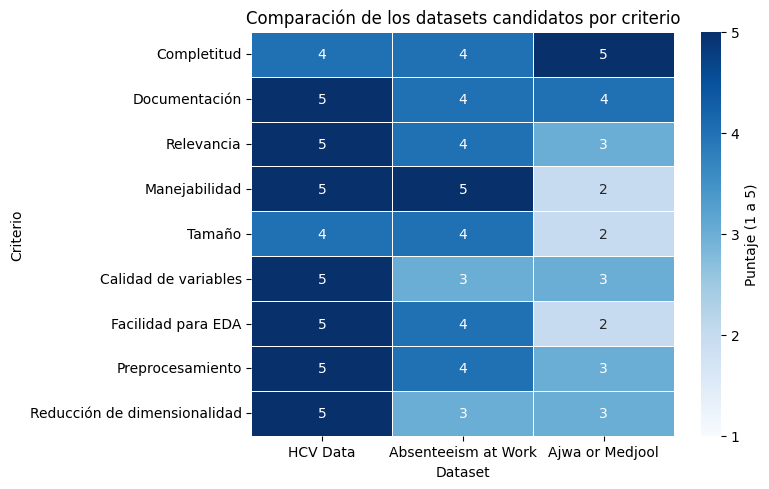

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(
    puntajes, annot=True, cmap="Blues", vmin=1, vmax=5,
    linewidths=0.5, cbar_kws={"label": "Puntaje (1 a 5)", "ticks": [1, 2, 3, 4, 5]}, ax=ax,
)
ax.set_title("Comparación de los datasets candidatos por criterio")
ax.set_xlabel("Dataset")
ax.set_ylabel("Criterio")
plt.tight_layout()
fig.savefig(RUTA_IMAGENES / "comparacion_datasets.png", dpi=120, bbox_inches="tight")
plt.show()

HCV Data queda con 43 de 45 puntos, Absenteeism at Work con 35 y Ajwa or Medjool con 27. En el mapa de calor se ve que HCV no tiene ningún criterio flojo, mientras que Absenteeism pierde en calidad de variables y reducción de dimensionalidad, y Ajwa pierde sobre todo en manejabilidad, tamaño y facilidad para el EDA.

## Dataset seleccionado

**Elegimos HCV Data** para el EDA (notebook 02) y para el preprocesamiento y la reducción de dimensionalidad (notebook 03). Las razones:

1. **Completitud.** Tiene muy pocos faltantes (0.39 % de las celdas), así que no se pierde información importante. A la vez, esos faltantes nos dejan practicar lo que pide el enunciado sobre cuantificarlos y proponer una estrategia de tratamiento.
2. **Documentación.** Viene de UCI, trae la descripción de cada variable y tiene un artículo publicado que explica de dónde salen los datos. La guía de la semana 3 recomienda justamente escoger bases con buena documentación.
3. **Relevancia.** Son datos clínicos reales: 10 marcadores de laboratorio, edad, sexo y el diagnóstico de cada paciente. Esto permite plantear preguntas con sentido, por ejemplo si los marcadores cambian entre donantes sanos y pacientes, y luego validarlas con t de Student o chi-cuadrado como en la semana 6.
4. **Manejabilidad y tamaño.** Es un solo CSV de 45 KB con 615 registros y 13 atributos. La guía de la semana 3 recomienda bases de tamaño medio para el EDA; HCV está un poco por encima de lo que sugiere (100 a 300 filas y 5 a 10 columnas), pero se sigue trabajando sin problema en pandas y alcanza para comparar donantes sanos contra pacientes.
5. **Calidad de variables.** Los marcadores son medidas continuas de verdad, no códigos. `Sex` y `Category` son las únicas categóricas y están claramente identificadas, así que no hay riesgo de tratar como número algo que no lo es.
6. **Preprocesamiento y reducción.** Tiene todo lo que pide la fase 3: faltantes para tratar, variables categóricas para codificar y marcadores en escalas muy distintas (de menos de 10 hasta más de 1000) que hay que estandarizar antes del PCA. Además, `Category` sirve para colorear los puntos de PC1 vs PC2 y ver si los grupos se separan.

**Aspectos a tener en cuenta en el EDA:** el desbalance de `Category` (86.67 % donantes sanos) y los faltantes concentrados en `ALP` y `CHOL`.